# Heart Disease Prediction
## Author [M. ARSALAN AKHTAR](https://github.com/git-arsalan/01_ML_Project_HeartDisease)
### Date:07-11-2026
### Dataset:[Heart Disease UCI Data](https://www.kaggle.com/datasets/redwankarimsony/heart-disease-data?resource=download)



## Meta Data About Dataset

### Context
This is a multivariate type of dataset which means providing or involving a variety of separate mathematical or statistical variables, multivariate numerical data analysis. It is composed of 14 attributes which are age, sex, chest pain type, resting blood pressure, serum cholesterol, fasting blood sugar, resting electrocardiographic results, maximum heart rate achieved, exercise-induced angina, oldpeak — ST depression induced by exercise relative to rest, the slope of the peak exercise ST segment, number of major vessels and Thalassemia. This database includes 76 attributes, but all published studies relate to the use of a subset of 14 of them. The Cleveland database is the only one used by ML researchers to date. One of the major tasks on this dataset is to predict based on the given attributes of a patient that whether that particular person has heart disease or not and other is the experimental task to diagnose and find out various insights from this dataset which could help in understanding the problem more.

### Content
#### Column Descriptions:
* 'id' (Unique id for each patient)
* 'age' (Age of the patient in years)
* 'origin' (place of study)
* 'sex' (Male/Female)
* 'cp' chest pain type ([typical angina, atypical angina, non-anginal, asymptomatic])
* 'trestbps' resting blood pressure (resting blood pressure (in mm Hg on admission to the hospital))
* 'chol' (serum cholesterol in mg/dl)
* 'fbs' (if fasting blood sugar > 120 mg/dl)
* 'restecg' (resting electrocardiographic results)
* -- 'Values': [normal, stt abnormality, lv hypertrophy]
* 'thalach': maximum heart rate achieved
* 'exang': exercise-induced angina (True/ False)
* 'oldpeak': ST depression induced by exercise relative to rest
* 'slope': the slope of the peak exercise ST segment
* 'ca': number of major vessels (0-3) colored by fluoroscopy
* 'thal': [normal; fixed defect; reversible defect]
* 'num': the predicted attribute

### Acknowledgements
#### Creators:
* Hungarian Institute of Cardiology. Budapest: Andras Janosi, M.D.
* University Hospital, Zurich, Switzerland: William Steinbrunn, M.D.
* University Hospital, Basel, Switzerland: Matthias Pfisterer, M.D.
* V.A. Medical Center, Long Beach and Cleveland Clinic Foundation: Robert Detrano, M.D., Ph.D.
#### Relevant Papers:
* Detrano, R., Janosi, A., Steinbrunn, W., Pfisterer, M., Schmid, J., Sandhu, S., Guppy, K., Lee, S., & Froelicher, V. (1989). International application of a new probability algorithm for the diagnosis of coronary artery disease. American Journal of Cardiology, 64,304--310.
#### Web Link
* David W. Aha & Dennis Kibler. "Instance-based prediction of heart-disease presence with the Cleveland database." Web Link
* Gennari, J.H., Langley, P, & Fisher, D. (1989). Models of incremental concept formation. Artificial Intelligence, 40, 11--61. Web Link
#### Citation Request:
* The authors of the databases have requested that any publications resulting from the use of the data include the names of the principal investigator responsible for the data collection at each institution. They would be:

* Hungarian Institute of Cardiology. Budapest: Andras Janosi, M.D.
* University Hospital, Zurich, Switzerland: William Steinbrunn, M.D.
* University Hospital, Basel, Switzerland: Matthias Pfisterer, M.D.
* V.A. Medical Center, Long Beach and Cleveland Clinic Foundation:Robert Detrano, M.D., Ph.D.

## Aims and Objectives:
we will Update it after doing EDA


## Importing Necessary Libraries:
Now importing libraries needed to start the project

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

from sklearn.preprocessing import StandardScaler,MinMaxScaler,RobustScaler, LabelEncoder
from sklearn.impute import SimpleImputer,KNNImputer

from sklearn.experimental import enable_iterative_imputer
from sklearn.impute import IterativeImputer

# Machine Learning Lib
from sklearn.model_selection import train_test_split, GridSearchCV , cross_val_score
# for classification task
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier,AdaBoostClassifier,GradientBoostingClassifier
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score,confusion_matrix,classification_report

# ignore warnings
import warnings
warnings.filterwarnings('ignore')




## Loading Data Set

In [2]:
Hd_df = pd.read_csv('../01Dataset/heart_disease_uci.csv')
Hd_df.head()

,id,age,sex,dataset,cp,trestbps,chol,fbs,restecg,thalch,exang,oldpeak,slope,ca,thal,num
0,1,63,Male,Cleveland,typical angina,145.0,233.0,True,lv hypertrophy,150.0,False,2.3,downsloping,0.0,fixed defect,0
1,2,67,Male,Cleveland,asymptomatic,160.0,286.0,False,lv hypertrophy,108.0,True,1.5,flat,3.0,normal,2
2,3,67,Male,Cleveland,asymptomatic,120.0,229.0,False,lv hypertrophy,129.0,True,2.6,flat,2.0,reversable defect,1
3,4,37,Male,Cleveland,non-anginal,130.0,250.0,False,normal,187.0,False,3.5,downsloping,0.0,normal,0
4,5,41,Female,Cleveland,atypical angina,130.0,204.0,False,lv hypertrophy,172.0,False,1.4,upsloping,0.0,normal,0


## Exploratory Data Analysis (EDA)
### Now we will explore each column


In [3]:
# Now we will explore the datatype of each column
Hd_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 920 entries, 0 to 919
Data columns (total 16 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   id        920 non-null    int64  
 1   age       920 non-null    int64  
 2   sex       920 non-null    str    
 3   dataset   920 non-null    str    
 4   cp        920 non-null    str    
 5   trestbps  861 non-null    float64
 6   chol      890 non-null    float64
 7   fbs       830 non-null    object 
 8   restecg   918 non-null    str    
 9   thalch    865 non-null    float64
 10  exang     865 non-null    object 
 11  oldpeak   858 non-null    float64
 12  slope     611 non-null    str    
 13  ca        309 non-null    float64
 14  thal      434 non-null    str    
 15  num       920 non-null    int64  
dtypes: float64(5), int64(3), object(2), str(6)
memory usage: 115.1+ KB


In [4]:
# Now checking the shape of data
Hd_df.shape

(920, 16)

## Data Contains 920 Rows and 16 Columns

In [5]:
# also verifiying it with id Column
Hd_df['id'].min() , Hd_df['id'].max()

(np.int64(1), np.int64(920))

In [6]:
# Now exploring the age column
Hd_df['age'].min() , Hd_df['age'].max()

(np.int64(28), np.int64(77))

## Age Group for the dataset
### Here we can validate that Dataset Collected the data for Age group from 28 yrs to 77 yrs

<Axes: xlabel='age', ylabel='Count'>

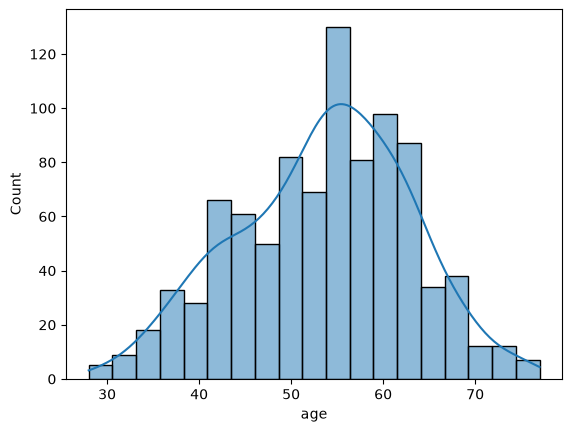

In [7]:
# NOW we draw histogram to visualize the distribution of age column
sns.histplot(Hd_df['age'],kde=True)

Mean=53.51086956521739
Mode=54
Mode=54.0


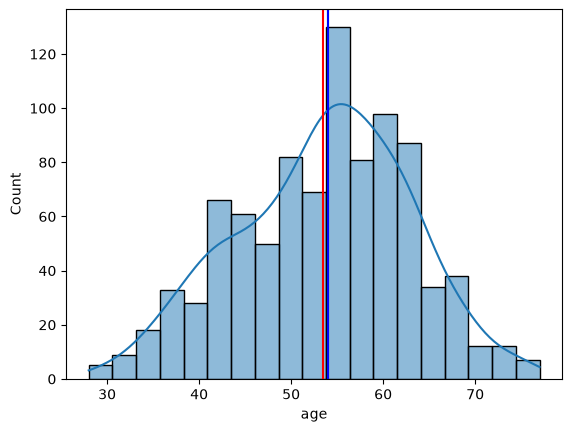

In [8]:
sns.histplot(Hd_df['age'],kde=True)
plt.axvline(Hd_df['age'].mean(), color='red') # getting mean line on hist plot
plt.axvline(Hd_df['age'].mode()[0], color='green') # getting mode line on hist plot
plt.axvline(Hd_df['age'].median(), color='blue') # getting medina line on hist plot

print(f"Mean={Hd_df['age'].mean()}")
print(f"Mode={Hd_df['age'].mode()[0]}")
print(f"Mode={Hd_df['age'].median()}")


#### Lets explore the Gender based distribution of heart column

In [10]:
# now we ploting the age column using plotly and differentiate it different color according to sex column
fig = px.histogram(data_frame=Hd_df, x='age', color='sex')
fig.show()

## OUTPUTS
1. Minimum age to have heart disease is 28 yrs
2. Maximum age to have heart disease is 78 yrs
3. Most of the people get heart disease at 53-54 yrs
4. Most of the Males and Females are with heart disease at the age 54-55.